In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Libraries loaded
TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# Load the merged dataset
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"From: {df.index.min().date()}")
print(f"To: {df.index.max().date()}")

Dataset loaded
Rows: 52461
Columns: 36
From: 2022-01-01
To: 2024-12-31


In [ ]:
# Define the feature set (includes demand_mw as input)
feature_cols = [
    'demand_mw',
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]

data = df[feature_cols].dropna()

print(f"Features selected: {len(feature_cols)}")
print(f"Rows after dropping NaN: {len(data)}")

Features selected: 21
Rows after dropping NaN: 52461


In [ ]:
# Split chronologically and scale features with MinMaxScaler
train_data = data[data.index.year.isin([2022, 2023])]
test_data  = data[data.index.year == 2024]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f"Training rows: {len(train_scaled):,}")
print(f"Test rows:     {len(test_scaled):,}")
print(f"Data scaled to range 0 to 1")

Training rows: 35,011
Test rows:     17,450
Data scaled to range 0 to 1


In [ ]:
# Build 48-step (24-hour) sliding-window sequences
def create_sequences(data, sequence_length=48):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i, 0])  # column 0 is demand_mw
    return np.array(X), np.array(y)

SEQ_LEN = 48  # 48 half-hour slots = 24 hours of history

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (34963, 48, 21)
y_train shape: (34963,)
X_test shape:  (17402, 48, 21)
y_test shape:  (17402,)


In [ ]:
# Define the LSTM architecture
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM with early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("LSTM training complete")

Epoch 1/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0096 - val_loss: 0.0041
Epoch 2/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0034 - val_loss: 0.0023
Epoch 3/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 4/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 5/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 6/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0013 - val_loss: 7.0564e-04
Epoch 7/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0012 - val_loss: 7.2600e-04
Epoch 8/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0011 - val_loss: 9.8329e-04
Epoch 9/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.9791e-04 - val_loss: 8.6367e-04
Epoch 10/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.1848e-04 - val_loss: 5.8003e-04
Epoch 11/50
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 8.8888e-04 - val_loss: 0.0012
Epoch 12/50
4

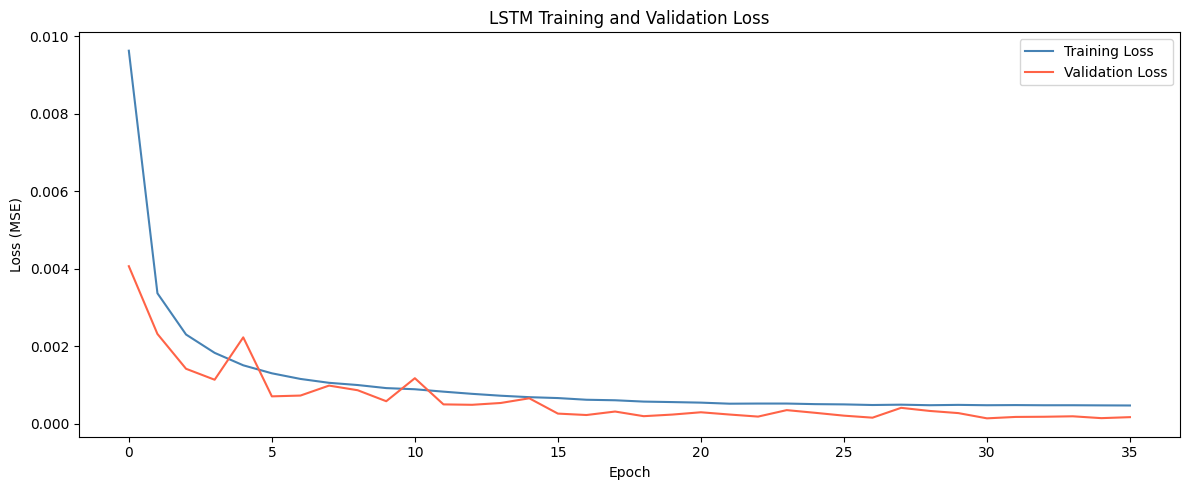

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='tomato')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step4_chart1_training_loss.png', dpi=150)
plt.show()



In [ ]:
# Generate predictions and inverse-transform to MW
predictions_scaled = model.predict(X_test)

# Create dummy arrays to inverse transform — scaler needs all columns
dummy_pred   = np.zeros((len(predictions_scaled), len(feature_cols)))
dummy_actual = np.zeros((len(y_test), len(feature_cols)))

dummy_pred[:, 0]   = predictions_scaled[:, 0]
dummy_actual[:, 0] = y_test

predictions_mw = scaler.inverse_transform(dummy_pred)[:, 0]
actual_mw      = scaler.inverse_transform(dummy_actual)[:, 0]

print(f"Predictions made: {len(predictions_mw):,}")
print(f"Sample actual values:    {actual_mw[:5].round(1)}")
print(f"Sample predicted values: {predictions_mw[:5].round(1)}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Predictions made: 17,402
Sample actual values:    [3227.  3146.  3056.5 2975.  2981.5]
Sample predicted values: [3216.4 3143.8 3054.3 2974.3 2917.4]


In [ ]:
# Build the results dataframe and compute overall RMSE/MAE
test_index = test_data.index[SEQ_LEN:]

results = pd.DataFrame({
    'actual'    : actual_mw,
    'predicted' : predictions_mw,
    'event_flag': test_data['event_flag'].values[SEQ_LEN:],
    'is_public_holiday': test_data['is_public_holiday'].values[SEQ_LEN:]
}, index=test_index)

overall_rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
overall_mae  = mean_absolute_error(results['actual'], results['predicted'])

event    = results[results['event_flag'] == 1]
nonevent = results[results['event_flag'] == 0]

event_rmse    = np.sqrt(mean_squared_error(event['actual'], event['predicted']))
event_mae     = mean_absolute_error(event['actual'], event['predicted'])
nonevent_rmse = np.sqrt(mean_squared_error(nonevent['actual'], nonevent['predicted']))
nonevent_mae  = mean_absolute_error(nonevent['actual'], nonevent['predicted'])

print("LSTM Model Performance on 2024 Test Set")
print(f"\nOverall RMSE: {round(overall_rmse, 2)} MW")
print(f"Overall MAE:  {round(overall_mae, 2)} MW")
print(f"\nEvent days RMSE: {round(event_rmse, 2)} MW")
print(f"Event days MAE:  {round(event_mae, 2)} MW")
print(f"\nNon-event days RMSE: {round(nonevent_rmse, 2)} MW")
print(f"Non-event days MAE:  {round(nonevent_mae, 2)} MW")

LSTM Model Performance on 2024 Test Set

Overall RMSE: 56.0 MW
Overall MAE:  42.6 MW

Event days RMSE: 52.2 MW
Event days MAE:  41.94 MW

Non-event days RMSE: 56.23 MW
Non-event days MAE:  42.64 MW


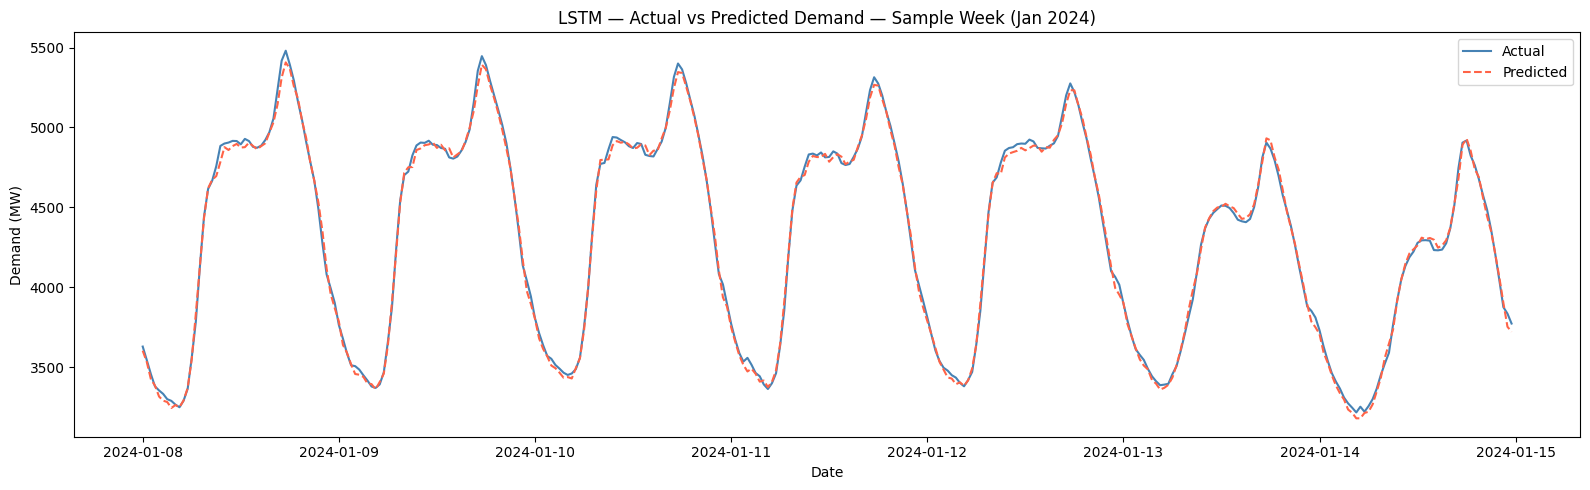

In [ ]:
# Plot actual vs predicted demand for a sample week
sample = results['2024-01-08':'2024-01-14']

plt.figure(figsize=(16, 5))
plt.plot(sample.index, sample['actual'],    color='steelblue', linewidth=1.5, label='Actual')
plt.plot(sample.index, sample['predicted'], color='tomato',    linewidth=1.5, label='Predicted', linestyle='--')
plt.title('LSTM — Actual vs Predicted Demand — Sample Week (Jan 2024)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step4_chart2_sample_week.png', dpi=150)
plt.show()

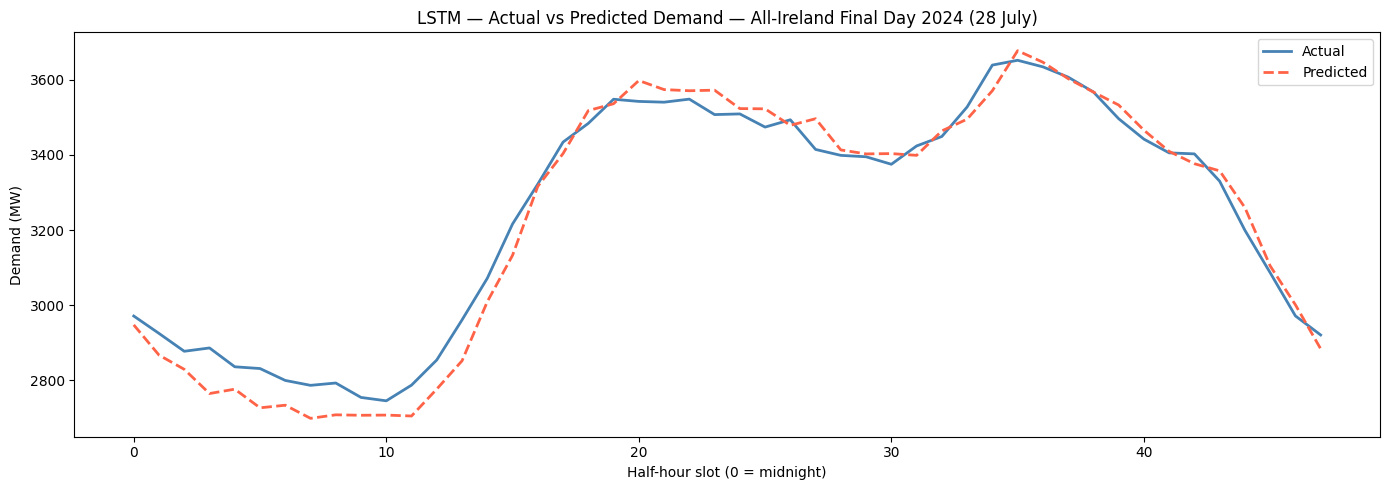

In [ ]:
# Plot actual vs predicted demand for the All-Ireland Final event day
event_date = pd.Timestamp('2024-07-28')
event_day  = results[results.index.date == event_date.date()]

plt.figure(figsize=(14, 5))
plt.plot(range(len(event_day)), event_day['actual'],    color='steelblue', linewidth=2, label='Actual')
plt.plot(range(len(event_day)), event_day['predicted'], color='tomato',    linewidth=2, label='Predicted', linestyle='--')
plt.title('LSTM — Actual vs Predicted Demand — All-Ireland Final Day 2024 (28 July)')
plt.xlabel('Half-hour slot (0 = midnight)')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step4_chart3_event_day.png', dpi=150)
plt.show()



In [ ]:
# Save the trained LSTM model and predictions
model.save('/content/lstm_model.keras')
results.to_csv('/content/lstm_predictions.csv')

print("LSTM model saved: lstm_model.keras")
print("Predictions saved: lstm_predictions.csv")
print("Step 4 complete")

LSTM model saved: lstm_model.keras
Predictions saved: lstm_predictions.csv
Step 4 complete
